Detached kernel driver
Found Rafael Micro R820T tuner
[R82XX] PLL not locked!
Exact sample rate is: 2000000.052982 Hz


[*] RTL-SDR Configurado a 917.0 MHz (Offset). Esperando señal en 917.5 MHz...


Allocating 15 zero-copy buffers


[*] Grabando 10.0 segundos...


Reattached kernel driver


[+] Captura finalizada. Total de muestras: 19988480
[*] Calculando espectro Max Hold...


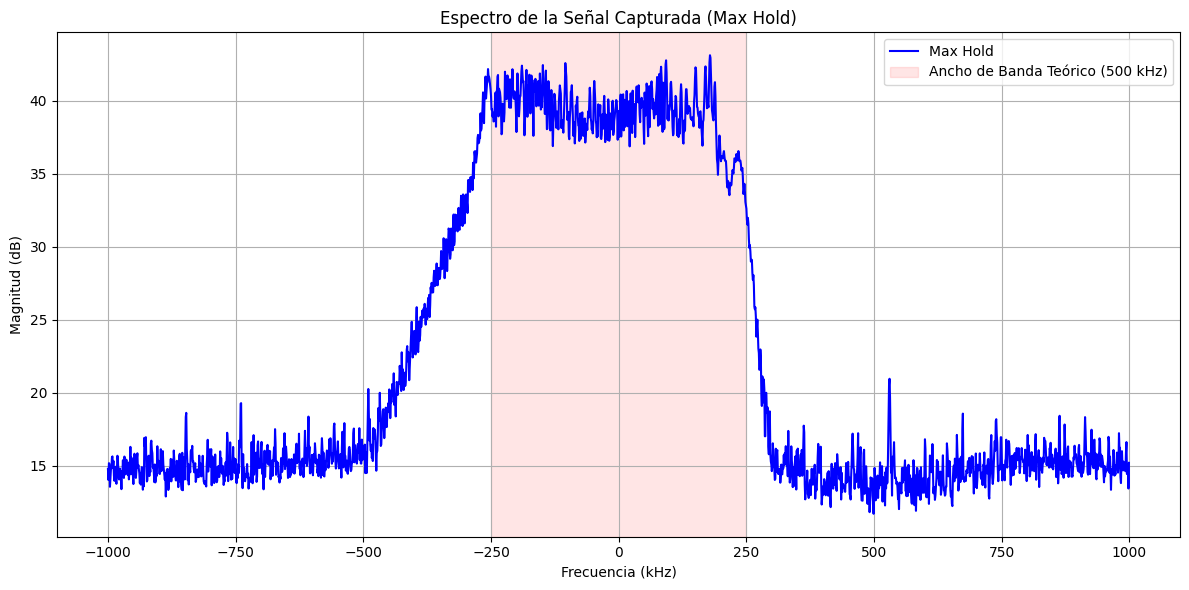

[+] Parámetros LoRa: SF=8, BW=500kHz, N=256, Os=4, N_sym=1024


In [23]:
import sys
import os
sys.path.append(os.path.abspath('../../'))

import numpy as np
import matplotlib.pyplot as plt
import time
from hardware.rtlsdr_handler import RtlSdrHandler

# ============================================================
# 1. CAPTURA Y GRÁFICO DE ESPECTRO (MAX HOLD)
# ============================================================
sample_rate = 2e6
target_freq = 917.5e6
offset_freq = 0.5e6
center_freq = target_freq - offset_freq

captured_samples = []
def rx_callback(samples):
    captured_samples.append(samples.copy())

sdr = RtlSdrHandler(rx_callback)
sdr.configurar(sample_rate, center_freq)
sdr.set_gain('auto')

print(f"[*] RTL-SDR Configurado a {center_freq/1e6} MHz (Offset). Esperando señal en {target_freq/1e6} MHz...")
sdr.start_rx()
time.sleep(2.0)
captured_samples.clear()

duration = 10.0
print(f"[*] Grabando {duration} segundos...")
time.sleep(duration)
sdr.stop_rx()
sdr.close()

iq_raw = np.concatenate(captured_samples)
print(f"[+] Captura finalizada. Total de muestras: {len(iq_raw)}")

# Offset Tuning: movemos la señal a banda base
t_raw = np.arange(len(iq_raw)) / sample_rate
iq_base = iq_raw * np.exp(-1j * 2 * np.pi * offset_freq * t_raw)

# Calculamos el espectro con retención de máximos (Max Hold)
nfft = 2048
print("[*] Calculando espectro Max Hold...")
num_blocks = len(iq_base) // nfft
max_hold = np.zeros(nfft)

for i in range(num_blocks):
    block = iq_base[i*nfft : (i+1)*nfft]
    # Aplicamos ventana Blackman para reducir fuga espectral
    windowed = block * np.blackman(nfft)
    # FFT y shift
    S = np.fft.fftshift(np.fft.fft(windowed))
    mag = 20 * np.log10(np.abs(S) + 1e-12)
    max_hold = np.maximum(max_hold, mag)

freqs = np.fft.fftshift(np.fft.fftfreq(nfft, d=1/sample_rate)) / 1e3 # en kHz

plt.figure(figsize=(12, 6))
plt.plot(freqs, max_hold, color='blue', label='Max Hold')
plt.axvspan(-250, 250, color='red', alpha=0.1, label='Ancho de Banda Teórico (500 kHz)')
plt.title('Espectro de la Señal Capturada (Max Hold)')
plt.xlabel('Frecuencia (kHz)')
plt.ylabel('Magnitud (dB)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# PARÁMETROS LoRa Y CHIRPS DE REFERENCIA
# ============================================================
BW = 500e3
SF = 8
N = 2**SF                          # 256 chips por símbolo
Os = int(sample_rate / BW)         # Factor de sobremuestreo: 4
N_sym = N * Os                     # 1024 muestras por símbolo
T_sym = N / BW                     # Duración del símbolo en segundos

# Chirp base (up-chirp no modulado, s=0)
# Frecuencia instantánea: f(t) = -BW/2 + (BW/T_sym)*t
# Fase: φ(t) = 2π * ∫f(τ)dτ = 2π * (-BW/2 * t + BW/(2*T_sym) * t²)
t_chirp = np.arange(N_sym) / sample_rate
phase_up = 2 * np.pi * (-BW/2 * t_chirp + BW/(2*T_sym) * t_chirp**2)
base_up_chirp = np.exp(1j * phase_up)
base_down = np.conj(base_up_chirp)

print(f"[+] Parámetros LoRa: SF={SF}, BW={BW/1e3:.0f}kHz, N={N}, Os={Os}, N_sym={N_sym}")


[*] Ejecutando Detección Gruesa del Preámbulo según guía matemática...
[*] Procesando 78076 ventanas (Stride=256 muestras)...
[+] ¡Preámbulo detectado! Inicio aproximado en la muestra 7655680
[+] Bin CFO detectado (k_coarse): 934
[+] PAPR de la primera ventana: 332.96


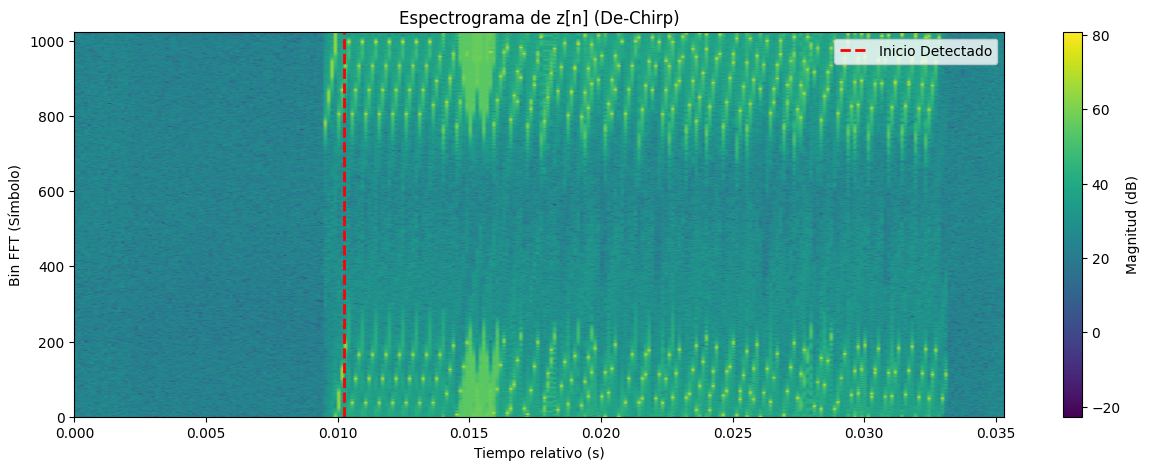

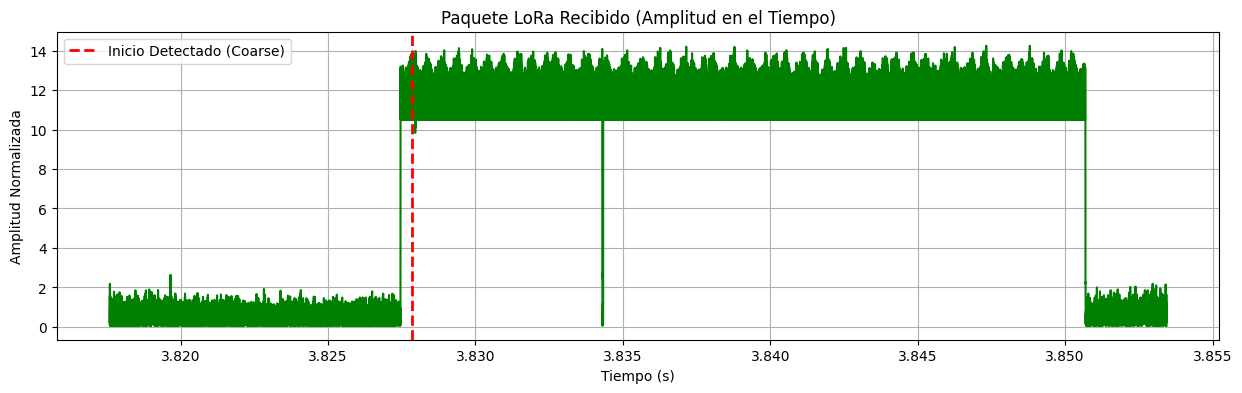

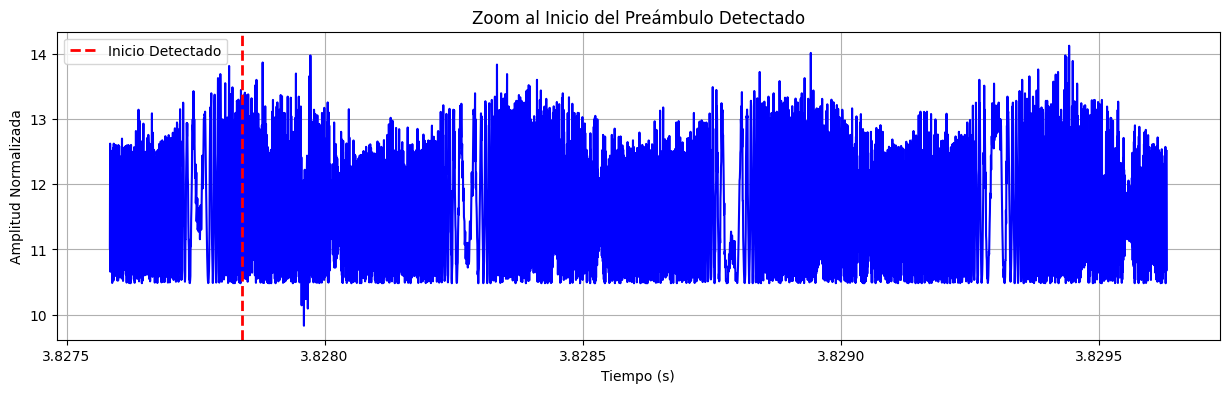

In [24]:
# ============================================================
# 2. ETAPA 1: DETECCIÓN GRUESA DEL PREÁMBULO (Sliding Window)
# ============================================================

print("[*] Ejecutando Detección Gruesa del Preámbulo según guía matemática...")

# 1. Normalización de Ganancia
iq_norm = iq_base / np.std(iq_base)

# Parámetros del algoritmo de ventana deslizante
N_samples = N_sym
h = N_samples // 4  # Zancada de N_samples / 4
PAPR_THRESHOLD = 10.0
M = 4 # Número de símbolos consecutivos requeridos

num_windows = (len(iq_norm) - N_samples) // h
papr_history = np.zeros(num_windows)
bin_history = np.zeros(num_windows, dtype=int)

print(f"[*] Procesando {num_windows} ventanas (Stride={h} muestras)...")
for i in range(num_windows):
    start_idx = i * h
    window_iq = iq_norm[start_idx : start_idx + N_samples]
    
    # De-chirping
    z = window_iq * base_down
    
    # FFT
    Z = np.fft.fft(z)
    Z_mag_sq = np.abs(Z)**2
    
    # Métrica de Detección (PAPR)
    max_Z_sq = np.max(Z_mag_sq)
    avg_Z_sq = np.mean(Z_mag_sq)
    papr = max_Z_sq / avg_Z_sq
    
    papr_history[i] = papr
    bin_history[i] = np.argmax(Z_mag_sq)

# Búsqueda de M símbolos consecutivos en la misma alineación
# Como el salto es N_samples/4, un símbolo entero son 4 ventanas.
stride_per_sym = N_samples // h
detected_window = -1

for i in range(num_windows - M * stride_per_sym):
    if papr_history[i] < PAPR_THRESHOLD:
        continue
        
    target_bin = bin_history[i]
    valid = True
    for m in range(1, M):
        idx = i + m * stride_per_sym
        # Tolerancia de +-1 bin por ruido/CFO fraccional
        bin_diff = abs(bin_history[idx] - target_bin)
        bin_diff = min(bin_diff, N_samples - bin_diff)
        
        if papr_history[idx] < PAPR_THRESHOLD or bin_diff > 2:
            valid = False
            break
            
    if valid:
        detected_window = i
        break

if detected_window != -1:
    coarse_start_idx = detected_window * h
    print(f"[+] ¡Preámbulo detectado! Inicio aproximado en la muestra {coarse_start_idx}")
    print(f"[+] Bin CFO detectado (k_coarse): {bin_history[detected_window]}")
    print(f"[+] PAPR de la primera ventana: {papr_history[detected_window]:.2f}")
else:
    print("[-] No se detectó ningún preámbulo.")
    coarse_start_idx = 0

# ============================================================
# GRÁFICOS
# ============================================================
if detected_window != -1:
    # 0. Espectrograma del De-Chirp (FFT de z) alrededor del paquete
    # Calculamos el espectrograma de la señal de-chirped solo en la región del paquete
    burst_len = int(50 * N_samples)
    start_plot = max(0, coarse_start_idx - 20 * N_samples)
    end_plot = min(len(iq_norm), coarse_start_idx + burst_len)
    
    spec_windows = (end_plot - start_plot - N_samples) // h
    spectrogram = np.zeros((N_samples, spec_windows))
    
    for w in range(spec_windows):
        idx = start_plot + w * h
        chunk = iq_norm[idx : idx + N_samples]
        z_chunk = chunk * base_down
        Z_mag = 20 * np.log10(np.abs(np.fft.fft(z_chunk)) + 1e-12)
        spectrogram[:, w] = Z_mag
        
    plt.figure(figsize=(15, 5))
    plt.imshow(spectrogram, aspect='auto', origin='lower', cmap='viridis', 
               extent=[0, spec_windows * h / sample_rate, 0, N_samples])
    plt.axvline((coarse_start_idx - start_plot) / sample_rate, color='red', linestyle='--', linewidth=2, label='Inicio Detectado')
    plt.title('Espectrograma de z[n] (De-Chirp)')
    plt.xlabel('Tiempo relativo (s)')
    plt.ylabel('Bin FFT (Símbolo)')
    plt.colorbar(label='Magnitud (dB)')
    plt.legend()
    plt.show()
    
    # 1. Gráfico en el tiempo del paquete completo recibido
    # Asumimos una longitud de paquete segura de 30 símbolos
    burst_len = int(50 * N_samples)
    start_plot = max(0, coarse_start_idx - 20 * N_samples)
    end_plot = min(len(iq_norm), coarse_start_idx + burst_len)
    
    t_paquete = np.arange(start_plot, end_plot) / sample_rate
    paquete_iq = iq_norm[start_plot:end_plot]
    
    plt.figure(figsize=(15, 4))
    plt.plot(t_paquete, np.abs(paquete_iq), color='green')
    plt.axvline(coarse_start_idx / sample_rate, color='red', linestyle='--', linewidth=2, label='Inicio Detectado (Coarse)')
    plt.title('Paquete LoRa Recibido (Amplitud en el Tiempo)')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud Normalizada')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # 2. Gráfico con Zoom al inicio detectado (4 símbolos)
    zoom_start = max(0, coarse_start_idx - int(0.5 * N_samples))
    zoom_end = min(len(iq_norm), coarse_start_idx + int(3.5 * N_samples))
    
    t_zoom = np.arange(zoom_start, zoom_end) / sample_rate
    zoom_iq = iq_norm[zoom_start:zoom_end]
    
    plt.figure(figsize=(15, 4))
    plt.plot(t_zoom, np.abs(zoom_iq), color='blue')
    plt.axvline(coarse_start_idx / sample_rate, color='red', linestyle='--', linewidth=2, label='Inicio Detectado')
    plt.title('Zoom al Inicio del Preámbulo Detectado')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud Normalizada')
    plt.legend()
    plt.grid(True)
    plt.show()


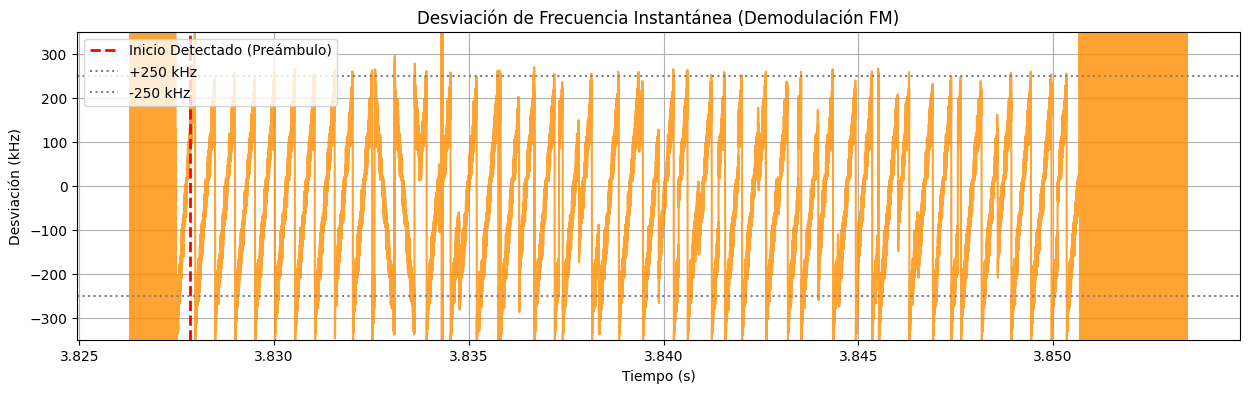

In [25]:
# ============================================================
# 3. DEMODULACIÓN FM (FRECUENCIA INSTANTÁNEA)
# ============================================================

if detected_window != -1:
    start_fm = max(0, coarse_start_idx - 3 * N_samples)
    burst_len = int(50 * N_samples)
    end_fm = min(len(iq_norm), coarse_start_idx + burst_len)
    
    iq_fm = iq_norm[start_fm:end_fm]
    t_fm = np.arange(start_fm, end_fm - 1) / sample_rate
    
    # Demodulación FM vectorizada (Derivada de la fase matemática)
    # f_inst[n] = Fs / (2*pi) * arg( x[n] * conj(x[n-1]) )
    f_inst = np.angle(iq_fm[1:] * np.conjugate(iq_fm[:-1])) * (sample_rate / (2 * np.pi))
    
    plt.figure(figsize=(15, 4))
    plt.plot(t_fm, f_inst / 1e3, color='darkorange', alpha=0.8)
    plt.axvline(coarse_start_idx / sample_rate, color='red', linestyle='--', linewidth=2, label='Inicio Detectado (Preámbulo)')
    plt.axhline(250, color='gray', linestyle=':', label='+250 kHz')
    plt.axhline(-250, color='gray', linestyle=':', label='-250 kHz')
    
    plt.title('Desviación de Frecuencia Instantánea (Demodulación FM)')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Desviación (kHz)')
    plt.ylim(-350, 350)
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("[-] Preámbulo no detectado, se omite el gráfico de FM.")


[*] Etapa A: Estimación Fraccionaria de Frecuencia (λ_CFO)
    -> Δf_FINE  = -647.58 Hz

[*] Etapa B: Desacoplamiento Directo (Sin decimar)
    -> Par seleccionado: ku=-90, kd=43
    -> K_CFO (bins) = -23.5
    -> K_STO (bins) = -66.5
    [!] Forzando alineación al límite izquierdo (-758 muestras en lugar de +266)

[*] Etapa C: Resincronización Total
    -> Offset Total de Frecuencia: -46546.02 Hz
    -> Alineación Temporal: 7655680 + (-758) = 7654922


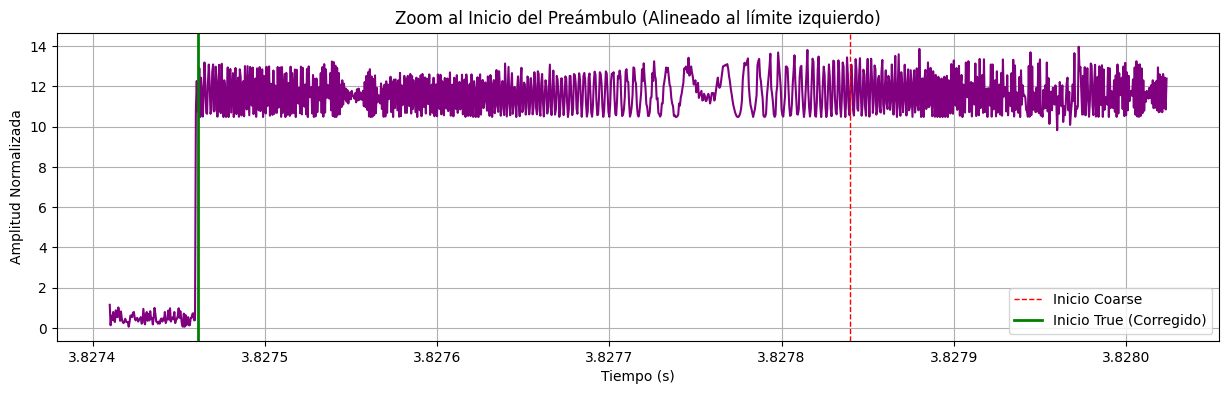

In [26]:
# ============================================================
# 4. ETAPA 2: DETECCIÓN FINA DE STO Y CFO
# ============================================================
# Fs = 2 MHz (Os=4). FFT de 1024 puntos.

if detected_window != -1:
    print("[*] Etapa A: Estimación Fraccionaria de Frecuencia (λ_CFO)")
    M_preamble = 5
    delta_phis = []
    for i in range(M_preamble):
        y_i    = iq_norm[coarse_start_idx + i * N_sym     : coarse_start_idx + (i+1) * N_sym]
        y_next = iq_norm[coarse_start_idx + (i+1) * N_sym : coarse_start_idx + (i+2) * N_sym]
        dphi = np.angle(np.sum(y_i * np.conj(y_next)))
        delta_phis.append(dphi)
    
    mean_dphi = np.mean(delta_phis)
    T_s = N_sym / sample_rate
    df_fine = -mean_dphi / (2 * np.pi * T_s)
    print(f"    -> Δf_FINE  = {df_fine:.2f} Hz")
    
    # Corrección fraccionaria
    n_arr = np.arange(len(iq_norm))
    iq_corr = iq_norm * np.exp(-1j * 2 * np.pi * df_fine * n_arr / sample_rate)
    
    print("\n[*] Etapa B: Desacoplamiento Directo (Sin decimar)")
    # Up-chirp (Símbolo 4)
    up_start = coarse_start_idx + 4 * N_sym
    up_sym = iq_corr[up_start : up_start + N_sym]
    fft_up = np.abs(np.fft.fft(up_sym * base_down))
    
    # Down-chirp (Símbolo 10)
    down_start = coarse_start_idx + 10 * N_sym
    down_sym = iq_corr[down_start : down_start + N_sym]
    fft_down = np.abs(np.fft.fft(down_sym * base_up_chirp))
    
    # Extraer picos principales (convertidos a -512..511)
    top_u = np.argsort(fft_up)[-3:][::-1]
    top_d = np.argsort(fft_down)[-3:][::-1]
    
    ku_cands = [k if k < N_sym//2 else k - N_sym for k in top_u]
    kd_cands = [k if k < N_sym//2 else k - N_sym for k in top_d]
    
    # Buscar el par (ku, kd) que provenga del MISMO segmento temporal.
    best_pair = None
    min_cfo_mag = float('inf')
    
    for ku in ku_cands:
        for kd in kd_cands:
            cfo_bin = (ku + kd) / 2
            if abs(cfo_bin) < min_cfo_mag:
                min_cfo_mag = abs(cfo_bin)
                best_pair = (ku, kd)
                
    ku_best, kd_best = best_pair
    K_CFO = (ku_best + kd_best) / 2
    K_STO = (ku_best - kd_best) / 2
    
    print(f"    -> Par seleccionado: ku={ku_best}, kd={kd_best}")
    print(f"    -> K_CFO (bins) = {K_CFO:.1f}")
    print(f"    -> K_STO (bins) = {K_STO:.1f}")
    
    bin_hz = sample_rate / N_sym
    cfo_entero_hz = K_CFO * bin_hz
    
    # 1 bin de desfase = Os muestras de tiempo
    # Si K_STO = (ku - kd)/2, entonces la fórmula correcta de desfase es:
    muestras_desfase = int(-K_STO * Os)
    
    # Forzar la alineación al límite IZQUIERDO (símbolo anterior) para que 
    # visualmente el inicio caiga siempre al principio de la energía capturada.
    if muestras_desfase > 0:
        print(f"    [!] Forzando alineación al límite izquierdo (-{N_sym - muestras_desfase} muestras en lugar de +{muestras_desfase})")
        muestras_desfase -= N_sym
    
    print("\n[*] Etapa C: Resincronización Total")
    df_total = cfo_entero_hz + df_fine
    print(f"    -> Offset Total de Frecuencia: {df_total:.2f} Hz")
    
    true_start_idx = coarse_start_idx + muestras_desfase
    print(f"    -> Alineación Temporal: {coarse_start_idx} + ({muestras_desfase}) = {true_start_idx}")
    
    # Corregir la frecuencia total
    iq_synced = iq_norm * np.exp(-1j * 2 * np.pi * df_total * n_arr / sample_rate)
    
    # Plot Zoom
    zoom_start = max(0, true_start_idx - int(0.1 * N_sym))
    zoom_end = min(len(iq_synced), true_start_idx + int(1.1 * N_sym))
    
    t_zoom = np.arange(zoom_start, zoom_end) / sample_rate
    zoom_iq = iq_synced[zoom_start:zoom_end]
    
    plt.figure(figsize=(15, 4))
    plt.plot(t_zoom, np.abs(zoom_iq), color='purple')
    plt.axvline(coarse_start_idx / sample_rate, color='red', linestyle='--', linewidth=1, label='Inicio Coarse')
    plt.axvline(true_start_idx / sample_rate, color='green', linestyle='-', linewidth=2, label='Inicio True (Corregido)')
    plt.title('Zoom al Inicio del Preámbulo (Alineado al límite izquierdo)')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud Normalizada')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("[-] Preámbulo no detectado.")


[*] Escaneando símbolos alrededor de true_start...
  Offset |   Bin (Up) |   Mag (Up) | Mag (Down)
------------------------------------------------------------
      -2 |         64 |       44.8 |       44.7 
      -1 |         41 |       42.6 |       58.0 
       0 |         24 |     1803.1 |      595.4 <-- true_start
       1 |          0 |    10931.6 |      655.9 
       2 |          0 |    10772.9 |      650.8 
       3 |          0 |    10746.3 |      676.8 
       4 |          0 |    10621.4 |      677.2 
       5 |          0 |    10488.5 |      655.0 
       6 |          0 |    10443.5 |      660.1 
       7 |          0 |    10289.5 |      667.9 
       8 |         24 |     9375.7 |     1156.1 
       9 |         32 |     9302.9 |     1109.9 
      10 |        190 |      665.1 |     4785.1 
      11 |        223 |      668.7 |     4970.3 
      12 |        101 |     4171.9 |     2805.8 
      13 |         49 |     5531.0 |     1174.8 
      14 |         49 |     2831.1 |      

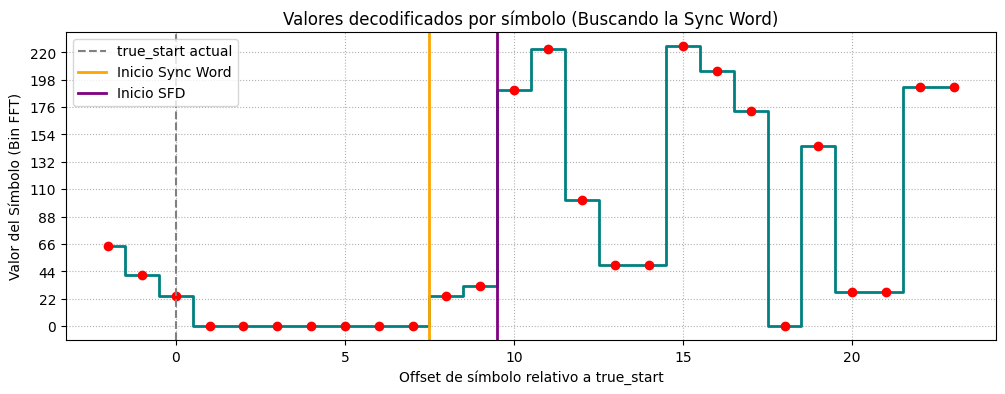

In [27]:
# ============================================================
# 5. ETAPA 3: DETECCIÓN DE LA SYNC WORD Y ALINEACIÓN DE FRAME
# ============================================================
# Demodulamos varios símbolos alrededor de nuestro true_start
# para encontrar el final del preámbulo y extraer la Sync Word.

if detected_window != -1:
    print("[*] Escaneando símbolos alrededor de true_start...")
    
    sym_offsets = range(-2, 24)
    decoded_vals = []
    peak_mags = []
    mags_down_list = []
    
    for k in sym_offsets:
        idx = true_start_idx + k * N_sym
        if idx < 0 or idx + N_sym > len(iq_synced):
            decoded_vals.append(-1)
            peak_mags.append(0)
            continue
            
        # Extraer símbolo y de-chirpear (asumimos up-chirp)
        sym_iq = iq_synced[idx : idx + N_sym]
        fft_val = np.abs(np.fft.fft(sym_iq * base_down))
        fft_val_down = np.abs(np.fft.fft(sym_iq * np.conj(base_down)))
        mag_down = np.max(fft_val_down[:N])
        
        # Buscar pico solo en la región válida (0 a N-1)
        peak_bin = np.argmax(fft_val[:N])
        
        decoded_vals.append(peak_bin)
        peak_mags.append(fft_val[peak_bin])
        mags_down_list.append(mag_down)
        
    # Imprimir tabla de resultados
    print(f"{'Offset':>8} | {'Bin (Up)':>10} | {'Mag (Up)':>10} | {'Mag (Down)':>10}")
    print("-" * 60)
    for k, val, mag, mag_d in zip(sym_offsets, decoded_vals, peak_mags, mags_down_list):
        marker = "<-- true_start" if k == 0 else ""
        print(f"{k:>8} | {val:>10} | {mag:>10.1f} | {mag_d:>10.1f} {marker}")
        
    # ===========================================================
    # Detección Algorítmica del Byte de Sync Word
    # ===========================================================
    preamble_end_idx = -1
    # Buscamos dónde se rompe la racha de ceros (preámbulo)
    for i in range(len(decoded_vals) - 3):
        # Tolerancia de +-1 bin por si hay ruido mínimo
        if all(abs(val) <= 1 or abs(val) >= N-1 for val in decoded_vals[i:i+4]):
            for j in range(i+4, len(decoded_vals)-1):
                if 1 < decoded_vals[j] < N-1:
                    preamble_end_idx = j
                    break
            if preamble_end_idx != -1:
                break
                
    if preamble_end_idx != -1 and preamble_end_idx + 1 < len(decoded_vals):
        sym1 = decoded_vals[preamble_end_idx]
        sym2 = decoded_vals[preamble_end_idx + 1]
        
        # Invertimos la lógica de Semtech: Símbolo = Nibble * 8
        nibble1 = round(sym1 / 8)
        nibble2 = round(sym2 / 8)
        sync_word = (nibble1 << 4) | nibble2
        
        print("\n[+] ¡Sync Word Aislada Exitosamente!")
        print(f"    Símbolos detectados: {sym1} y {sym2}")
        print(f"    Cálculo de Nibbles : {sym1}/8 = {nibble1} | {sym2}/8 = {nibble2}")
        print(f"    Valor de Registro  : 0x{sync_word:02X}")
        
        # Guardamos el índice donde arranca el SFD (justo después del Sync Word)
        sfd_start_offset = sym_offsets[preamble_end_idx + 2]
        print(f"    -> El SFD comienza en el offset {sfd_start_offset}")
    else:
        print("\n[-] No se pudo aislar la Sync Word automáticamente.")
        
    # Graficar la transición
    plt.figure(figsize=(12, 4))
    plt.step(sym_offsets, decoded_vals, where='mid', color='teal', linewidth=2)
    plt.plot(sym_offsets, decoded_vals, 'o', color='red')
    plt.axvline(0, color='gray', linestyle='--', label='true_start actual')
    if preamble_end_idx != -1:
        sw_offset = sym_offsets[preamble_end_idx]
        plt.axvline(sw_offset - 0.5, color='orange', linestyle='-', linewidth=2, label='Inicio Sync Word')
        plt.axvline(sw_offset + 1.5, color='purple', linestyle='-', linewidth=2, label='Inicio SFD')
    plt.title('Valores decodificados por símbolo (Buscando la Sync Word)')
    plt.xlabel('Offset de símbolo relativo a true_start')
    plt.ylabel('Valor del Símbolo (Bin FFT)')
    plt.yticks(range(0, max(decoded_vals)+10, max(1, max(decoded_vals)//10)))
    plt.grid(True, linestyle=':')
    plt.legend()
    plt.show()
else:
    print("[-] Preámbulo no detectado.")


In [28]:
# ============================================================                                                                                              
# 7. ETAPA 4: DECODIFICACIÓN DEL PHY HEADER                                                                                                                 
# ============================================================                                                                                              
if detected_window != -1:                                                                                                                                   
    print("[*] Extrayendo los 8 símbolos de la cabecera...")                                                                                                
    # La cabecera empieza exactamente 12.25 símbolos después del true_start                                                                                 
    # (0 a 8 preámbulo, 8 a 10 sync word, 10 a 12.25 SFD)                                                                                                   
    header_start_idx = true_start_idx + int(12.25 * N_sym)                                                                                                  
                                                                                                                                                            
    # Función para desmapeo de Gray                                                                                                                         
    def gray_decode(n):                                                                                                                                     
        mask = n >> 1                                                                                                                                       
        while mask != 0:                                                                                                                                    
            n = n ^ mask                                                                                                                                    
            mask = mask >> 1                                                                                                                                
        return n                                                                                                                                            
                                                                                                                                                            
    # --- PASO A: Demodulación FFT y Gray ---                                                                                                               
    header_syms = []                                                                                                                                        
    header_gray = []                                                                                                                                        
    peak_mags = []                                                                                                                                          
    for k in range(8):                                                                                                                                      
        idx = header_start_idx + k * N_sym                                                                                                                  
        sym_iq = iq_synced[idx : idx + N_sym]                                                                                                               
        fft_val = np.abs(np.fft.fft(sym_iq * base_down))  # Up-chirps                                                                                       
        peak_bin = np.argmax(fft_val[:N])                                                                                                                   
        header_syms.append(peak_bin)                                                                                                                        
        peak_mags.append(fft_val[peak_bin])                                                                                                                 
        header_gray.append(gray_decode(peak_bin))                                                                                                           
                                                                                                                                                            
    print(f"    -> Bins crudos (FFT): {header_syms}")                                                                                                       
    print(f"    -> Magnitudes de los picos: {[round(m, 1) for m in peak_mags]}")                                                                            
    print(f"    -> Bins desmapeados (Gray): {header_gray}")                                                                                                 
                                                                                                                                                            
    # --- PASO B: Desintercalado Diagonal ---                                                                                                               
    # Matriz I (8 símbolos x SF=8 bits)                                                                                                                     
    D = np.zeros((8, 8), dtype=int)                                                                                                                         
    for j in range(8):           # Índice de símbolo (columna original)                                                                                     
        val = header_gray[j]                                                                                                                                
        for i in range(8):       # Índice de bit (fila original)                                                                                            
            bit = (val >> i) & 1                                                                                                                            
            row = (i - (j + 1)) % 8                                                                                                                         
            D[row, i] = bit                                                                                                                                 
                                                                                                                                                            
    # --- PASO C: Extracción de Nibbles (Hamming) ---                                                                                                       
    # Imprimimos tanto los LSB como los MSB para verificar en qué lado cayeron los datos                                                                    
    nibbles_lsb = []                                                                                                                                        
    nibbles_msb = []                                                                                                                                        
    for row in range(8):                                                                                                                                    
        nl = sum((D[row, i] << i) for i in range(4))                                                                                                        
        nm = sum((D[row, i+4] << i) for i in range(4))                                                                                                      
        nibbles_lsb.append(nl)                                                                                                                              
        nibbles_msb.append(nm)                                                                                                                              
                                                                                                                                                            
    print(f"\n[*] Desintercalado completado.")                                                                                                              
    print(f"    -> Nibbles LSB (bits 0-3): {nibbles_lsb}")                                                                                                  
    print(f"    -> Nibbles MSB (bits 4-7): {nibbles_msb}")                                                                                                  
                                                                                                                                                            
    # --- PASO D: Extracción de Parámetros ---                                                                                                              
    # En LoRa, los datos están en los 4 bits más significativos (MSB) del codeword Hamming                                                                  
    header_bits = []                                                                                                                                        
    for n in nibbles_msb:                                                                                                                                   
        for i in range(4):                                                                                                                                  
            header_bits.append((n >> i) & 1)                                                                                                                
                                                                                                                                                            
    # Primeros 12 bits = Length (8), CR (3), CRC (1)                                                                                                        
    L_val = sum((header_bits[i] << i) for i in range(8))                                                                                                    
    CR_val = sum((header_bits[8 + i] << i) for i in range(3))                                                                                               
    CRC_flag = header_bits[11]                                                                                                                              
                                                                                                                                                            
    hc_val = sum((header_bits[12 + i] << i) for i in range(5))                                                                                              
                                                                                                                                                            
    print(f"\n[*] Parámetros del PHY Header:")
    print(f"    -> Payload Length (L): {L_val} bytes")
    print(f"    -> Coding Rate (CR): 4/{CR_val + 4}")
    print(f"    -> CRC Presente: {'Sí' if CRC_flag else 'No'}")
    print(f"    -> Header Checksum (hc): {hc_val}")
    print(f"    -> Bits crudos de info: {''.join(str(b) for b in header_bits[:17])}")
else:
    print("[-] Preámbulo no detectado.")

[*] Extrayendo los 8 símbolos de la cabecera...
    -> Bins crudos (FFT): [165, 113, 33, 13, 241, 61, 57, 209]
    -> Magnitudes de los picos: [4079.8, 5464.1, 8570.6, 8995.4, 844.9, 7453.9, 7680.9, 2157.8]
    -> Bins desmapeados (Gray): [198, 94, 62, 9, 161, 41, 46, 158]

[*] Desintercalado completado.
    -> Nibbles LSB (bits 0-3): [14, 14, 7, 13, 9, 8, 2, 14]
    -> Nibbles MSB (bits 4-7): [2, 1, 11, 0, 5, 4, 10, 10]

[*] Parámetros del PHY Header:
    -> Payload Length (L): 18 bytes
    -> Coding Rate (CR): 4/7
    -> CRC Presente: Sí
    -> Header Checksum (hc): 16
    -> Bits crudos de info: 01001000110100001
